<a href="https://colab.research.google.com/github/Sharif2138/MLOP-Summative-assignment-/blob/main/MLOP_Summative_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Early Skin Diseases Detection Using Deep Learning**


##**Dataset Description**



In [1]:
#install kaggle CLI
!pip install kaggle

In [2]:
#uploading kaggle token file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sharifkiviiri","key":"49648c580abb165d5ee35772bb65bd96"}'}

In [3]:
#moving the file to kaggle config folder
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
#download dataset
!rm -rf dataset*
!kaggle datasets download -d hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
!unzip melanoma-skin-cancer-dataset-of-10000-images.zip -d ./dataset >/dev/null 2>&1
!ls

Dataset URL: https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images
License(s): CC0-1.0
100% 98.7M/98.7M [00:00<00:00, 169MB/s]

dataset      melanoma-skin-cancer-dataset-of-10000-images.zip
kaggle.json  sample_data


In [5]:
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()

2.19.0


'/device:GPU:0'

##**Data Pipeleine**

Proper preprocessing is critical for model performance. The steps applied to this dataset are:

**Val and train split**. The train folder was turned into file paths and split into vlidation dataset and train dataset

**Image resizing:** All images were resized to a fixed size to make input uniform.
**Normalization:** Pixel values were scaled to improve model convergence and training stability.

**Data augmentation:** For CNN models, images were randomly flipped, rotated, and zoomed to increase dataset diversity and reduce overfitting.


In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from tensorflow.keras import layers
from tensorflow.keras import models, layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [7]:
#
train_dataset = Path("/content/dataset/melanoma_cancer_dataset/train")
train_images = list(train_dataset.glob('*/*.jpg'))
train_labels = [path.parent.name for path in train_images]

val_dataset = Path("/content/dataset/melanoma_cancer_dataset/test")
val_images = list(val_dataset.glob('*/*.jpg'))
val_labels = [path.parent.name for path in val_images]


all_labels = train_labels + val_labels

encoder = LabelEncoder()
encoder.fit(all_labels)

train_labels_encoded = encoder.transform(train_labels)
val_labels_encoded = encoder.transform(val_labels)

num_classes = len(encoder.classes_)
joblib.dump(encoder, "encoder.pkl")


#forming a tf.data datasets
train_data = tf.data.Dataset.from_tensor_slices(([str(p) for p in train_images], train_labels_encoded))
val_data = tf.data.Dataset.from_tensor_slices(([str(p) for p in val_images], val_labels_encoded))


#function to load the images
def load_images(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, [224,224])
  img = preprocess_input(img)

  return img, label

#preprocess
Batch_size = 64
autotune = tf.data.AUTOTUNE

train_data = train_data.map(load_images, num_parallel_calls = autotune)
val_data = val_data.map(load_images, num_parallel_calls = autotune)

#data augmentation
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

def augment(img, label):
    return data_aug(img, training=True), label

train_data = train_data.shuffle(1000)

train_data = train_data.map(augment, num_parallel_calls=autotune)

#CPU and GPU optimizatitions
train_data = train_data.batch(Batch_size).cache().prefetch(autotune)
val_data = val_data.batch(Batch_size).cache().prefetch(autotune)


for imgs, labels in train_data.take(1):
  print(f"image_shape: {imgs.shape}")
  print(f"labels_shape: {labels.shape}")

image_shape: (64, 224, 224, 3)
labels_shape: (64,)


#**Visualization of some images in the dataset**
I printed out some images to see how the data looks like

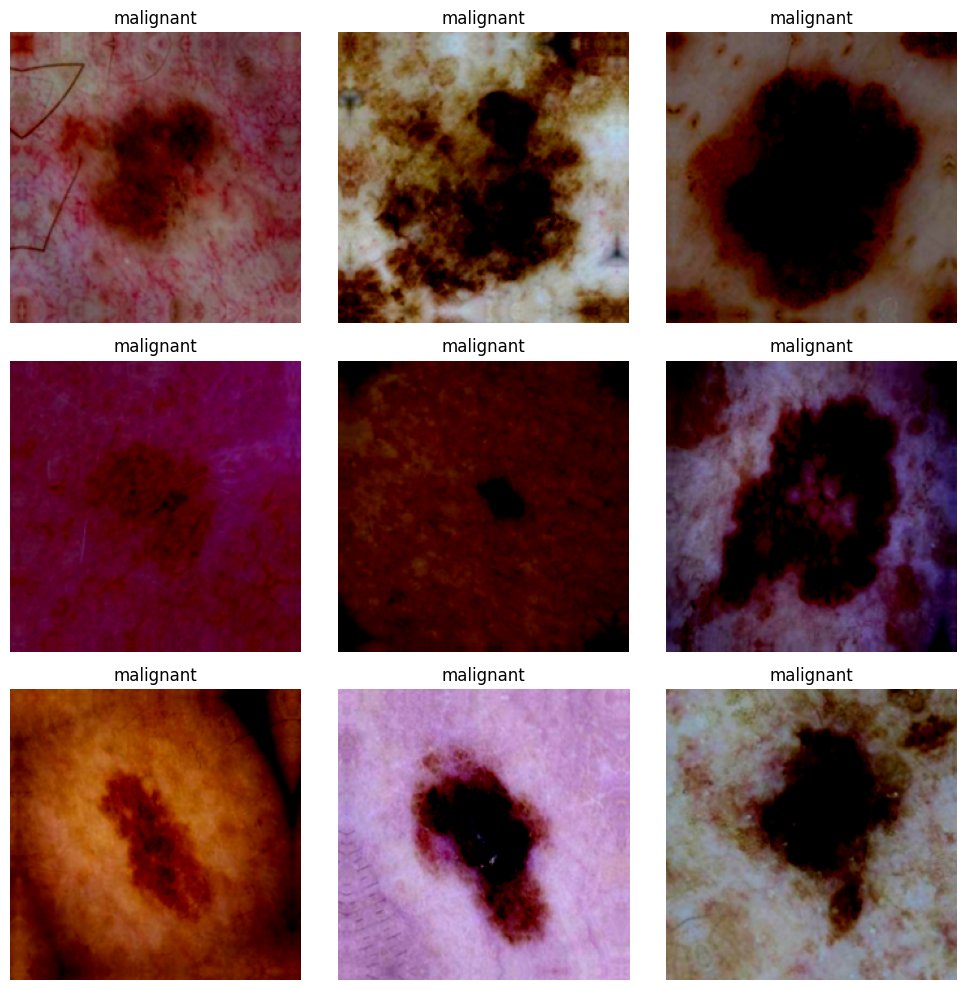

In [8]:
#visualise some images
plt.figure(figsize=(10, 10))
for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        class_name = encoder.classes_[labels[i]]
        plt.title(class_name)
        plt.axis("off")

plt.tight_layout()
plt.show()

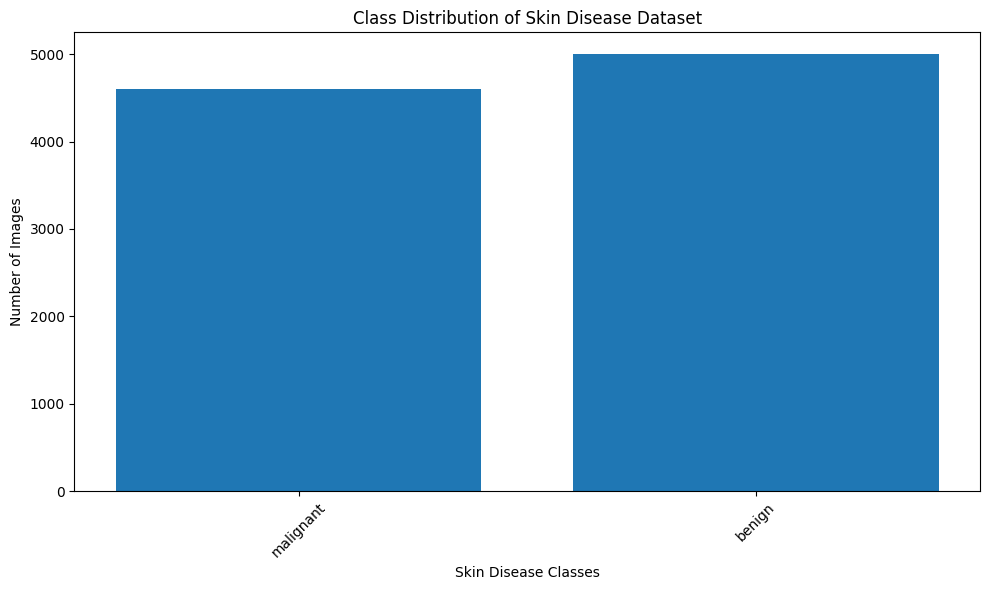

In [9]:
class_names = []
image_counts = []

# Loop through each class folder
for class_name in os.listdir(train_dataset):
    class_path = os.path.join(train_dataset, class_name)

    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))

        class_names.append(class_name)
        image_counts.append(count)

# Plot
plt.figure(figsize=(10,6))
plt.bar(class_names, image_counts)

plt.xlabel("Skin Disease Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Skin Disease Dataset")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()


#**Deep Learning**
I did 5 experiments in this group
I started by building advanced CNN models

Below is the method to run iterations on advanced CNN. Iterations of Learning rate, dropout and regularizer


In [10]:
#Transfer learning
base_model = MobileNetV2(
     weights = "imagenet",
     include_top =False,
     input_shape =(224, 224, 3)
)

base_model.trainable = False

#custom classifier
model = tf.keras.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor = "val_loss"),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    callbacks=callbacks,
    epochs=50
)

with open("history.pkl", "wb") as f:
    pickle.dump(history.history, f)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 167s 954ms/step - accuracy: 0.9359 - loss: 2.0714 - val_accuracy: 0.5670 - val_loss: 2.3586
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9056 - loss: 1.0039 - val_accuracy: 0.6130 - val_loss: 1.9403
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9003 - loss: 0.6710 - val_accuracy: 0.5730 - val_loss: 1.8297
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8935 - loss: 0.5335 - val_accuracy: 0.5400 - val_loss: 1.8288
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.8865 - loss: 0.4968 - val_accuracy: 0.5670 - val_loss: 1.7265
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8770 - loss: 0.4985 - val_accuracy: 0.5590 - val_loss: 1.6390
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8489 - loss: 0.5265 - val_accuracy: 0.6020 - val_loss: 1.5834
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 50

In [11]:
test_loss, test_acc = model.evaluate(val_data, verbose=1)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")


y_true = []
y_pred = []

for images, labels in val_data:
    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7020 - loss: 0.6438
Test Accuracy: 0.7020
Test Loss:     0.6438
Precision: 0.81328320802005
Recall: 0.702
F1-score: 0.6729573000759442


Plotted loss and accuracy curves for experiment 7

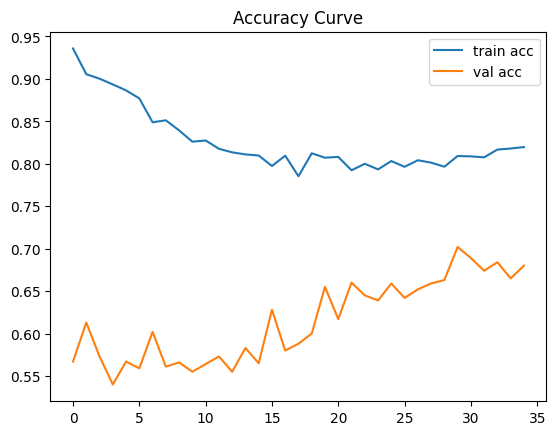

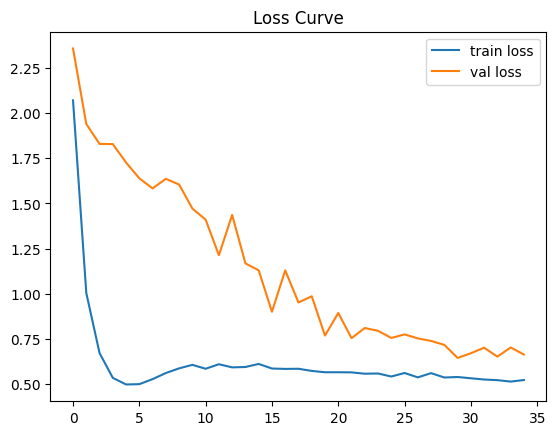

In [12]:
#Plot val accuracy and loss curves
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("Accuracy_curve.png")
plt.show()


plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()



Plotted confusion matrix for experiment 7

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 324ms/step


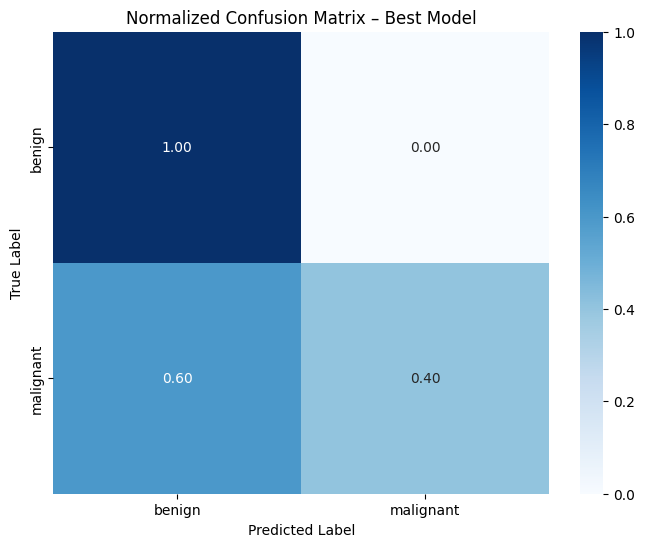

In [13]:
y_pred = np.argmax(model.predict(val_data), axis=1)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

plt.figure(figsize=(8,6))

class_names = encoder.classes_

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Best Model")
plt.savefig("confusion_matrix.png")
plt.show()

#fine tuning

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False


callbacks_fine = [
    tf.keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=2,
        factor=0.2,
        min_lr=1e-7
    )
]


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)


fine_tune_history = model.fit(
    train_data,
    validation_data=val_data,
    callbacks=callbacks_fine,
    epochs=15
)


with open("fine_tune_history.pkl", "wb") as f:
    pickle.dump(fine_tune_history.history, f)

model.save("skin_disease_detection.keras")
print('model saved successfully')

Epoch 1/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 58s 215ms/step - accuracy: 0.5705 - loss: 0.8266 - val_accuracy: 0.7570 - val_loss: 0.5395 - learning_rate: 3.0000e-06
Epoch 2/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step - accuracy: 0.6025 - loss: 0.7657 - val_accuracy: 0.7720 - val_loss: 0.5172 - learning_rate: 3.0000e-06
Epoch 3/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.6276 - loss: 0.7250 - val_accuracy: 0.7690 - val_loss: 0.5150 - learning_rate: 3.0000e-06
Epoch 4/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step - accuracy: 0.6502 - loss: 0.6933 - val_accuracy: 0.7700 - val_loss: 0.5169 - learning_rate: 3.0000e-06
Epoch 5/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - accuracy: 0.6656 - loss: 0.6687 - val_accuracy: 0.7710 - val_loss: 0.5172 - learning_rate: 3.0000e-06
Epoch 6/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 86ms/step - accuracy: 0.6861 - loss: 0.6440 - val_accuracy: 0.7750 - val_loss: 0.5143 - learning_rate: 6.0000e-07
Epoch 7/15
151/151 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/st

In [15]:

test_loss, test_acc = model.evaluate(val_data, verbose=1)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

y_true = []
y_pred = []

# TEST data for final evaluation
for images, labels in val_data:
    probs = model.predict(images, verbose=0)

    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7780 - loss: 0.5134
Test Accuracy: 0.7780
Test Loss:     0.5134
Precision: 0.7900716205612782
Recall: 0.778
F1-score: 0.7756660293695609


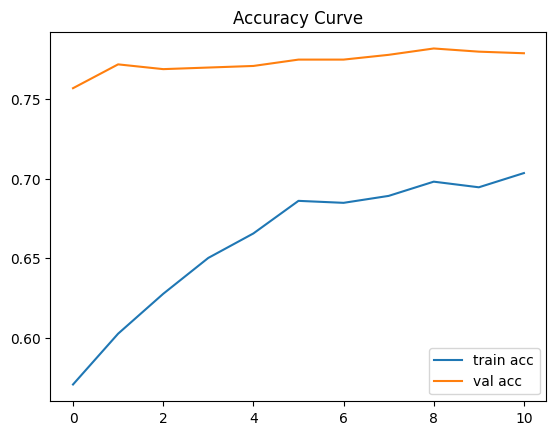

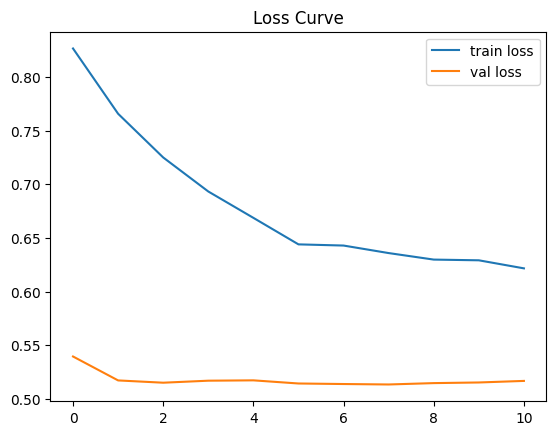

In [16]:
#Plot val accuracy and loss curves
plt.plot(fine_tune_history.history["accuracy"], label="train acc")
plt.plot(fine_tune_history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("Accuracy_curve.png")
plt.show()

plt.plot(fine_tune_history.history["loss"], label="train loss")
plt.plot(fine_tune_history.history["val_loss"], label="val loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()



16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 377ms/step


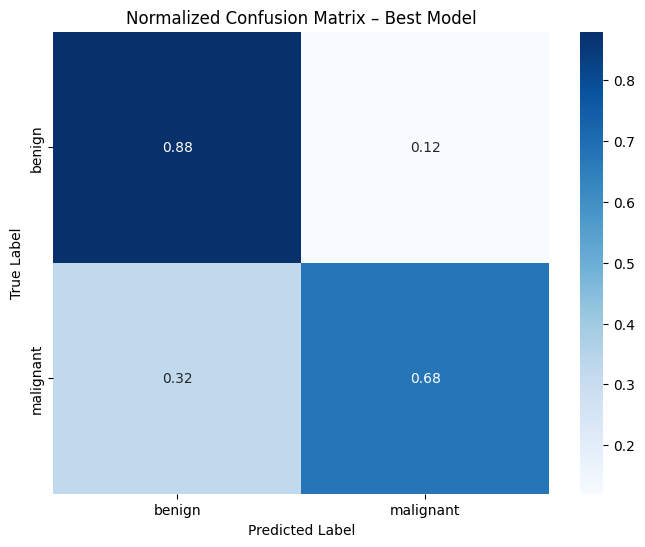

In [17]:
# predictions
y_pred = np.argmax(model.predict(val_data), axis=1)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)

plt.figure(figsize=(8,6))

class_names = encoder.classes_

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Best Model")
plt.savefig("confusion_matrix.png")
plt.show()

#**END**